# 04p3 — NDMM PBMC QC Plots: Cell-Level Metrics by Batch & Cell Type

### By [Mansi Singh](mansi.singh@alleninstitute.org), Comp Bio, Allen Institute for Immunology


**Aim:** Generate violin and bar plots of QC metrics (cell counts, UMIs, mitochondrial content, gene counts) stratified by sequencing pool/batch and cell type. Used to identify batch-level quality outliers

In [ ]:
# --- Load libraries (suppress startup messages) ---
quiet_library <- function(...) { suppressPackageStartupMessages(library(...)) }

quiet_library(dplyr)
quiet_library(hise)
quiet_library(H5weaver)
quiet_library(purrr)
quiet_library(tidyr)
library(ggplot2)
library(MASS)
library(patchwork)
library(tidyverse)

In [ ]:
# Read metadata with manual doublet annotations
ndmm_meta <- read.csv('../../../data/rna/NDMM_pbmc_193samples_doublet_metadata_all_types.csv')

In [4]:
dim(ndmm_meta)

[1] 2944774     103

In [ ]:
# Filter to non-doublet cells only
meta <- ndmm_meta %>% filter(doublets_manual == 'no')
cat(sprintf("Cells after doublet removal: %s\n", format(nrow(meta), big.mark=",")))

In [ ]:
# Select relevant QC and annotation columns
meta <- meta %>% dplyr::select(
    batch_id, pool_id,
    n_genes, n_mito_umis, n_reads, n_umis,
    pbmc_sample_id, sample.visitName, sample.visitDetails,
    subject.subjectGuid, sample.sampleKitGuid,
    pct_counts_mito,
    tidy.aifi_l3, tidy.aifi_l2, tidy.aifi_l1
)

## 2 QC Metric Plots by Pool/Batch

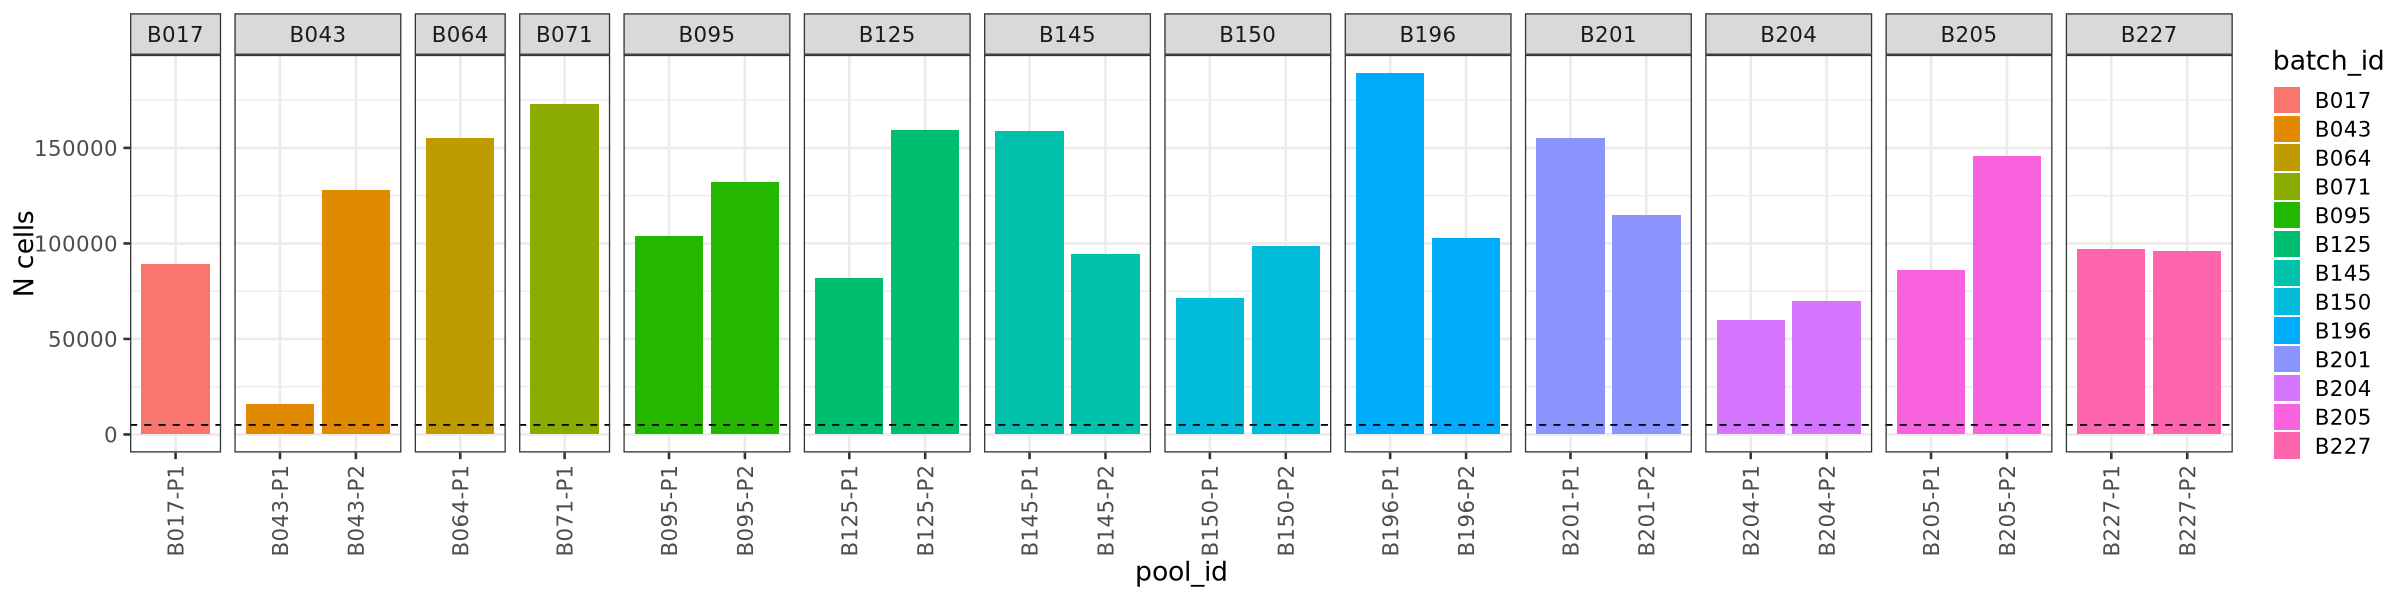

In [ ]:
# Bar plot: cell counts per pool, faceted by batch
# Dashed line at 5,000 cells = minimum expected cells per pool
options(repr.plot.width = 20, repr.plot.height = 5)
g_cells <- meta %>%
    ggplot(aes(pool_id, fill = batch_id)) +
        geom_bar(position = 'dodge') +
        ylab('N cells') +
        geom_hline(linetype = 2, yintercept = 5000) +
        theme_bw(base_size = 16) +
        facet_grid(~batch_id, space = 'free', scales = 'free_x') +
        theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))
g_cells

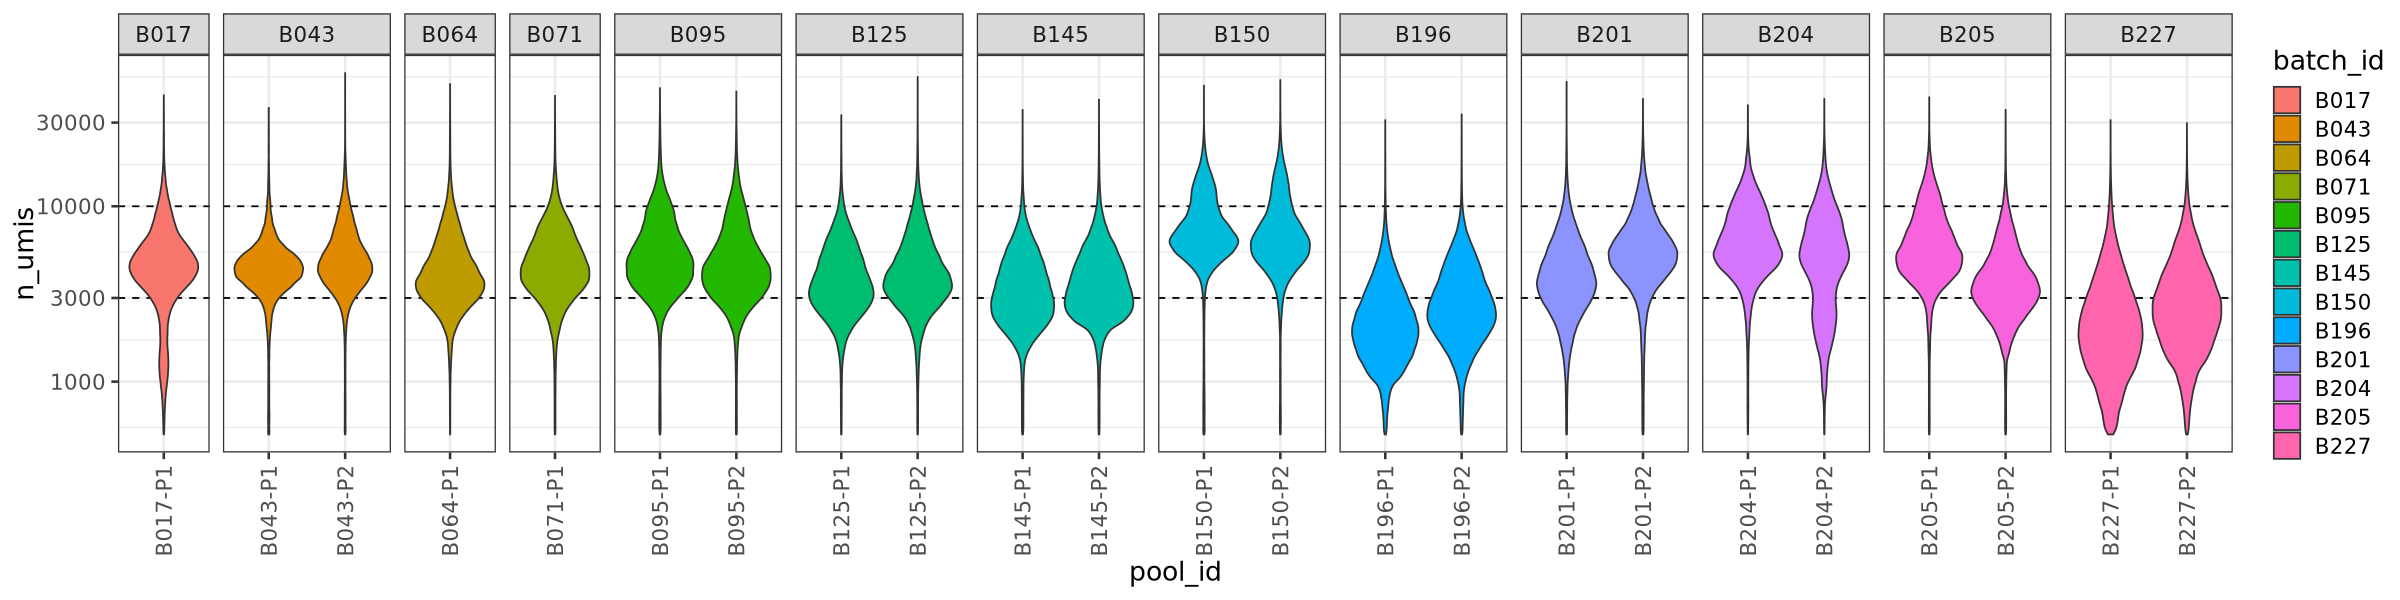

In [ ]:
# Violin: UMI counts per pool (log10 scale)
# Dashed lines: 10,000 (high) & 3,000 (low) UMI thresholds
options(repr.plot.width = 20, repr.plot.height = 5)
g_umis <- meta %>%
    ggplot(aes(pool_id, n_umis, fill = batch_id)) +
        geom_hline(linetype = 2, yintercept = 10000) +
        geom_hline(linetype = 2, yintercept = 3000) +
        geom_violin(position = 'dodge') +
        scale_y_log10() +
        theme_bw(base_size = 16) +
        facet_grid(~batch_id, space = 'free', scales = 'free_x') +
        theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))
g_umis

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 380 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


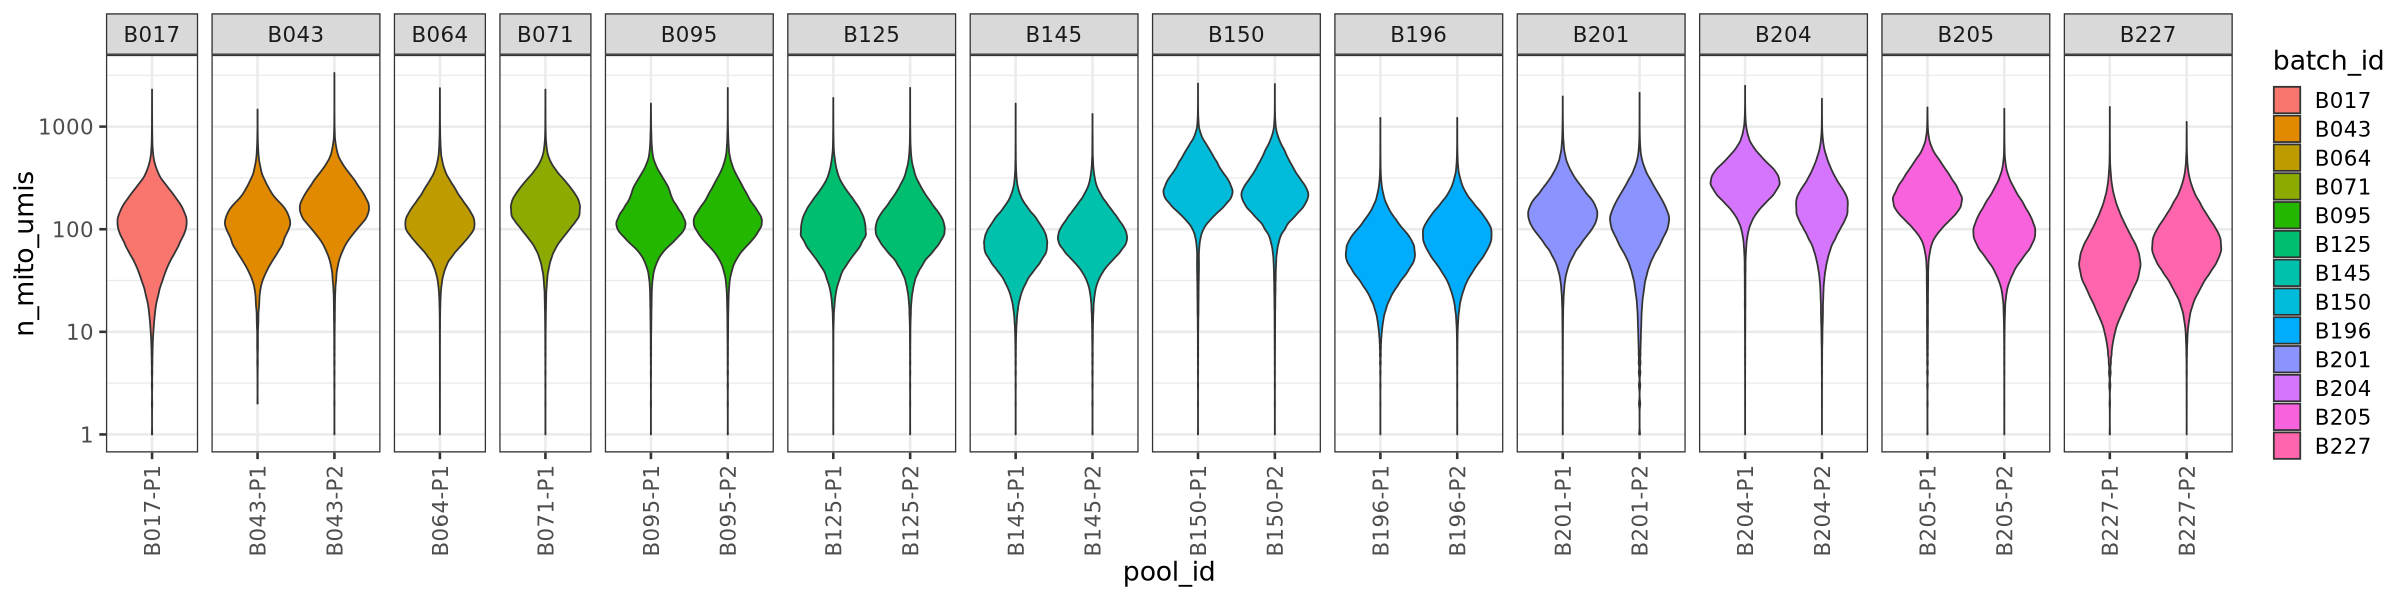

In [ ]:
# Violin: mitochondrial UMI counts per pool (log10 scale)
g_mito <- meta %>%
    ggplot(aes(pool_id, n_mito_umis, fill = batch_id)) +
        geom_violin(position = 'dodge') +
        scale_y_log10() +
        theme_bw(base_size = 16) +
        facet_grid(~batch_id, space = 'free', scales = 'free_x') +
        theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))
g_mito

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 380 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


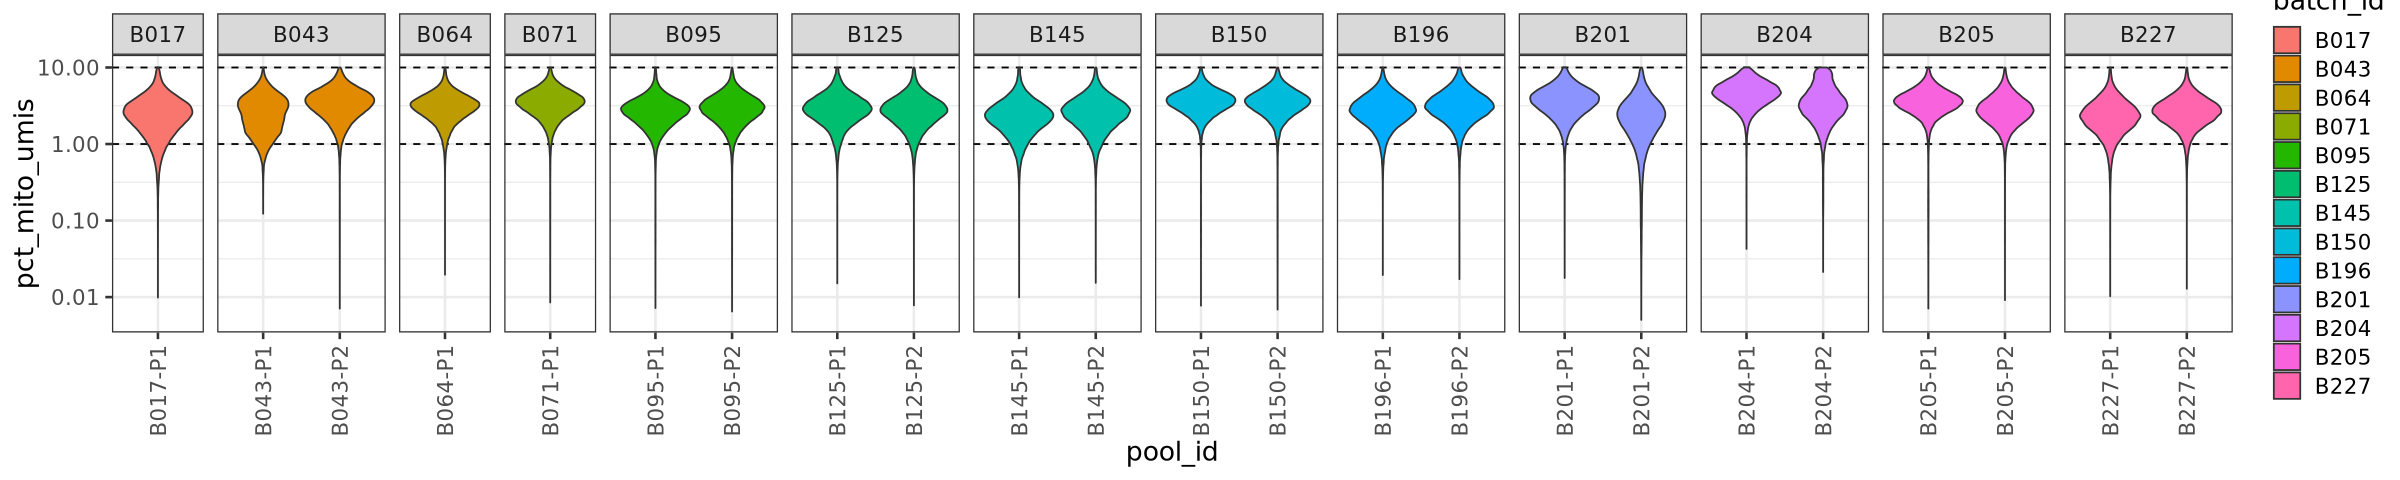

In [ ]:
# Violin: % mitochondrial UMIs per pool (log10 scale)
# Dashed lines: 10% (upper QC cutoff used in 04) and 1% (reference floor)
options(repr.plot.width = 20, repr.plot.height = 4)
g_mito_pct <- meta %>%
    mutate(pct_mito_umis = n_mito_umis / n_umis * 100) %>%
    ggplot(aes(pool_id, pct_mito_umis, fill = batch_id)) +
        geom_hline(linetype = 2, yintercept = 10) +
        geom_hline(linetype = 2, yintercept = 1) +
        geom_violin(position = 'dodge') +
        scale_y_log10() +
        theme_bw(base_size = 16) +
        facet_grid(~batch_id, space = 'free', scales = 'free_x') +
        theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))
g_mito_pct

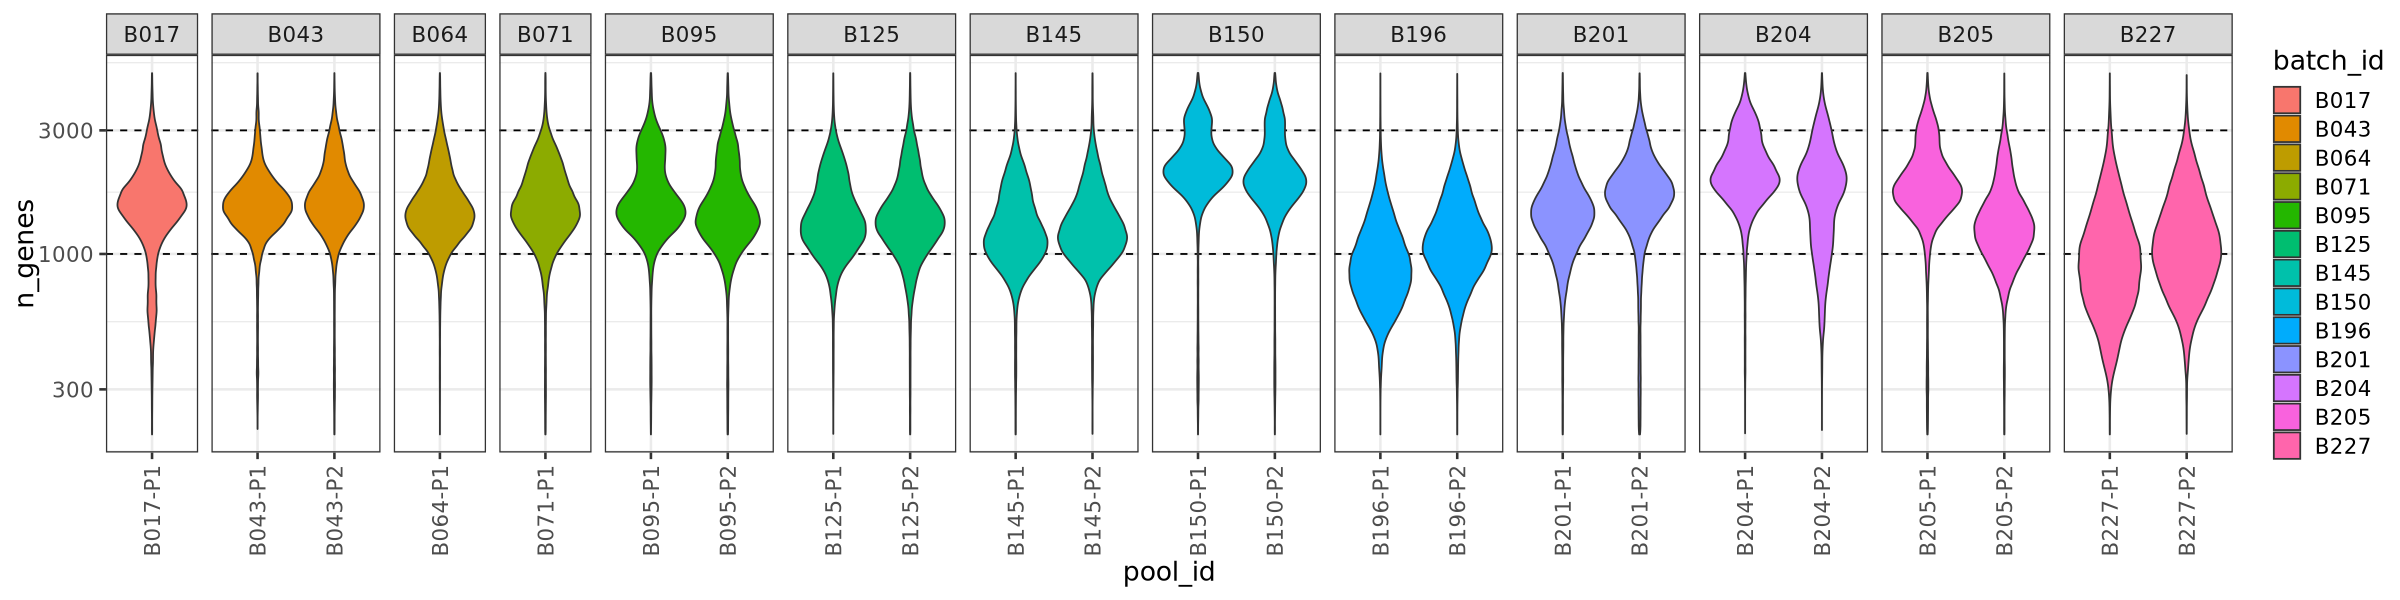

In [ ]:
# Violin: gene counts per pool (log10 scale)
# Dashed lines: 3,000 (upper reference) and 1,000 (lower reference)
g_genes <- meta %>%
    ggplot(aes(pool_id, n_genes, fill = batch_id)) +
        geom_hline(linetype = 2, yintercept = 3000) +
        geom_hline(linetype = 2, yintercept = 1000) +
        geom_violin(position = 'dodge') +
        scale_y_log10() +
        theme_bw(base_size = 16) +
        facet_grid(~batch_id, space = 'free', scales = 'free_x') +
        theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))
g_genes

In [ ]:
# Shared theme modifier: remove x-axis labels for stacked panels
no_x <- theme(axis.text.x = element_blank())

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 380 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


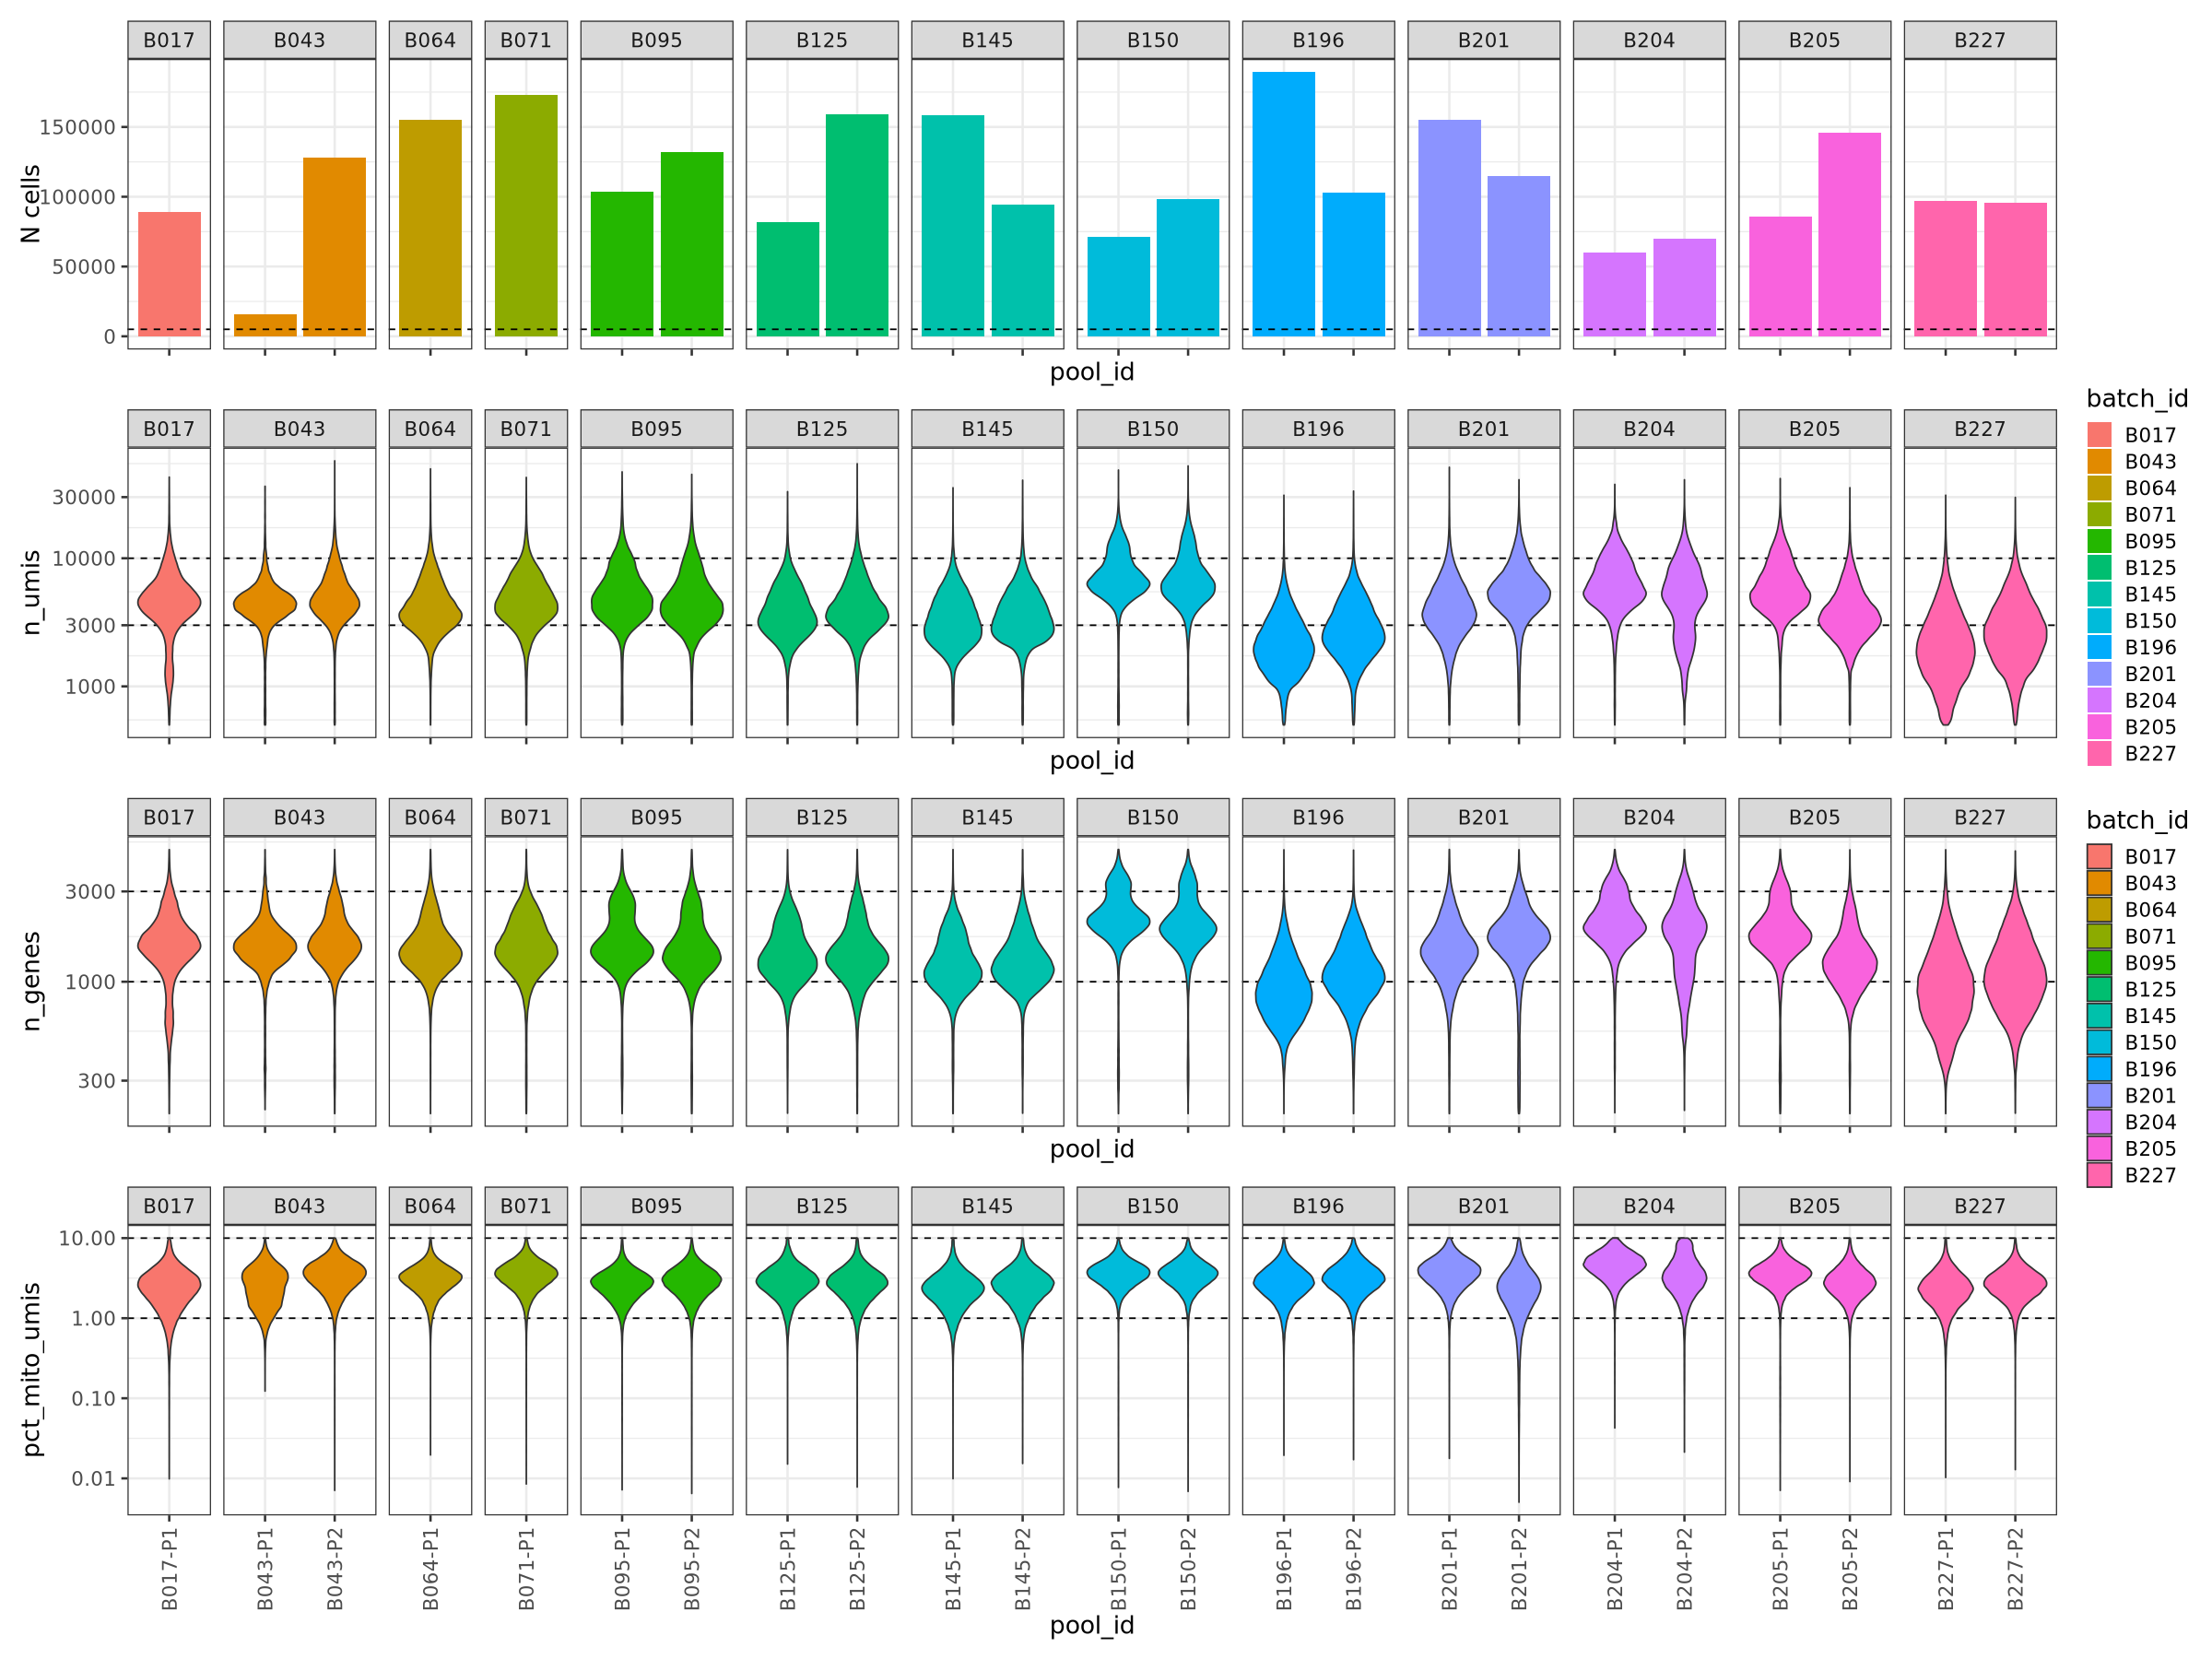

In [ ]:
# Combined panel: all QC metrics stacked vertically (x-axis shown only on bottom plot)
options(repr.plot.width = 20, repr.plot.height = 15)
wrap_plots(
    (g_cells + no_x),
    (g_umis + no_x),
    (g_genes + no_x),
    g_mito_pct,
    guides = 'collect', ncol = 1
)

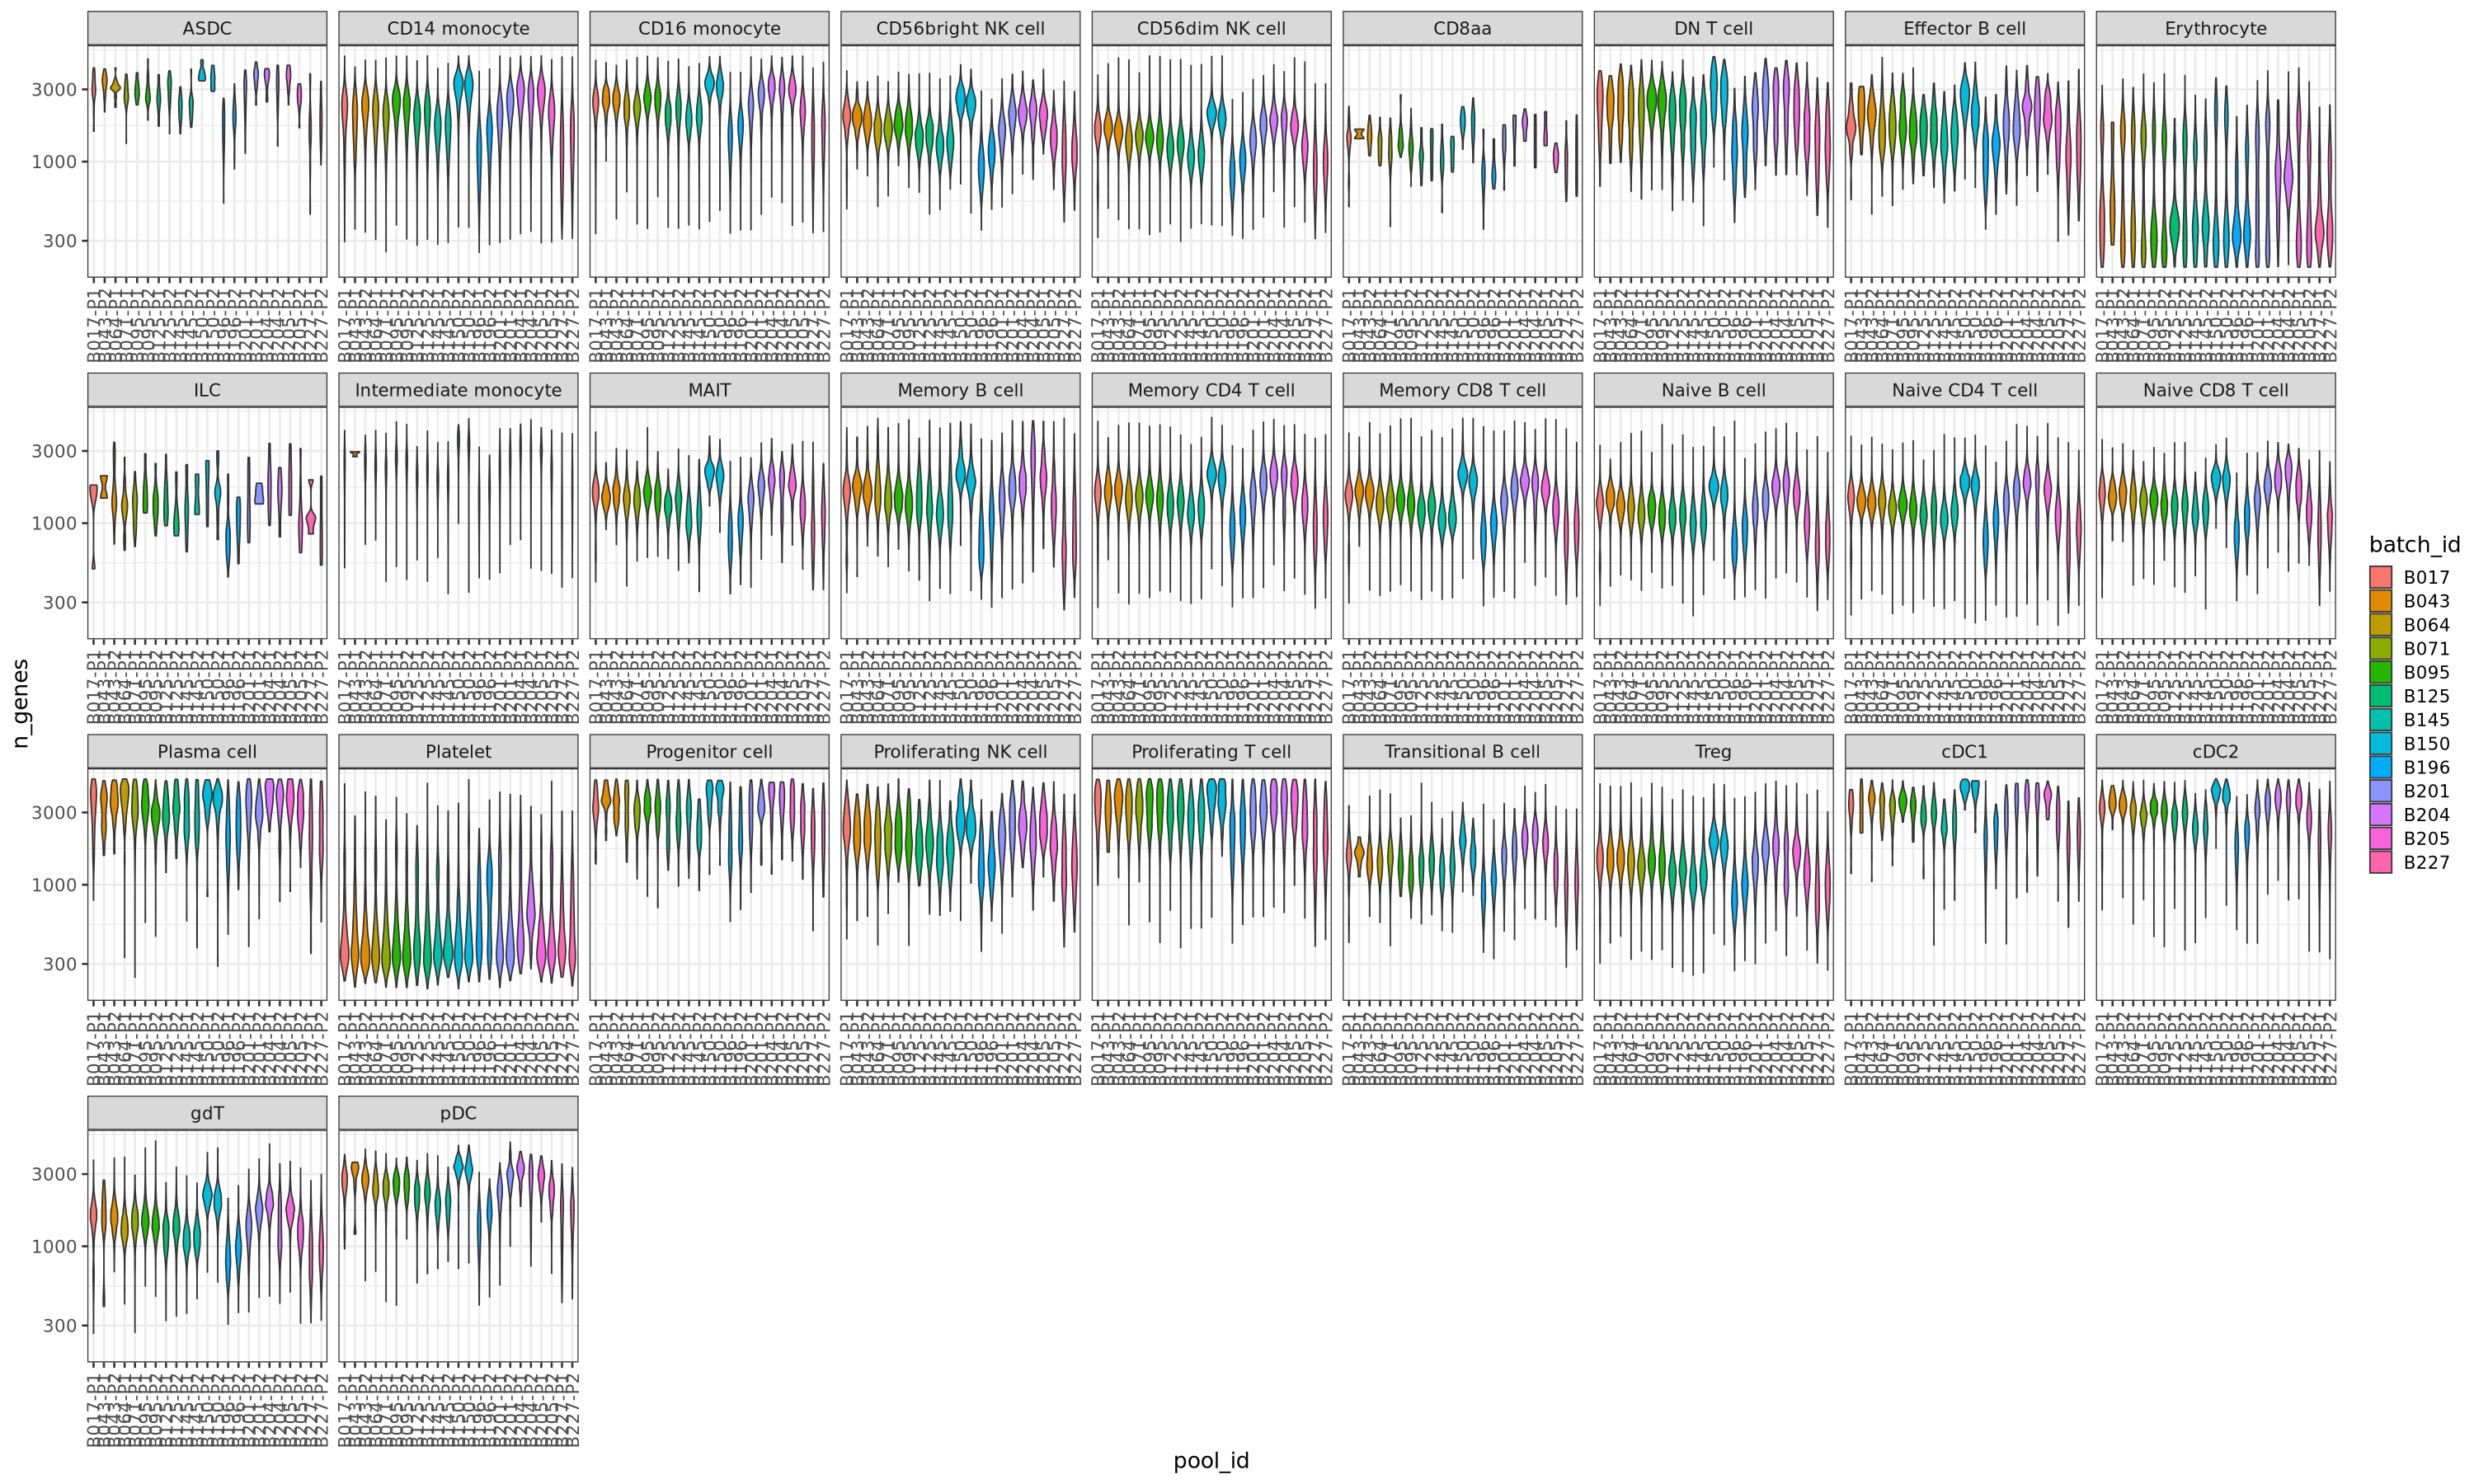

In [ ]:
# Gene counts per pool, faceted by L2 cell type — checks for cell-type-specific batch effects
options(repr.plot.width = 25, repr.plot.height = 15)
meta %>%
    ggplot(aes(pool_id, n_genes, fill = batch_id)) +
        geom_violin(position = 'dodge') +
        scale_y_log10() +
        theme_bw(base_size = 16) +
        facet_wrap(~tidy.aifi_l2, scales = 'free_x', ncol = 9) +
        theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))